In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('/content/online_shoppers_intention.csv')

In [4]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.shape

(12330, 18)

In [6]:
df.isnull().sum()

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
df.duplicated().sum()

np.int64(125)

In [9]:
before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 12330
Rows after: 12205
Duplicates removed: 125


In [10]:
df["Revenue"].value_counts()

,count
Revenue,
False,10297
True,1908


In [11]:
df["Revenue"].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.367063
True,15.632937


In [12]:
df.dtypes

,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


In [13]:
categorical_cols = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 Month
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

 OperatingSystems
OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64

 Browser
Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64

 Region
Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64

 TrafficType
TrafficType
2     3911
1     2388
3     2013
4     1066
13     728
10     450
6      443
8      343
5      260
11     247
20     193
9       41
7       40
15      37
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

 VisitorType
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other            

Exploratory Data Analysis


In [14]:
## 1. Overall Purchase Conversion Rate

# Calculate the percentage of converting and non-converting sessions
conversion_summary = (
    df["Revenue"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

conversion_summary

,proportion
Revenue,
False,84.37
True,15.63


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

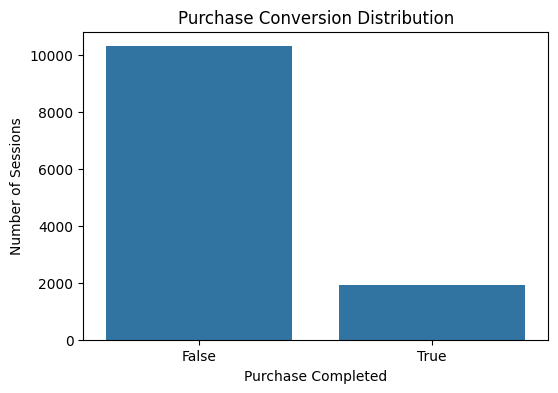

In [16]:
# Visualizing the number of converting and non-converting sessions
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Revenue")

plt.title("Purchase Conversion Distribution")
plt.xlabel("Purchase Completed")
plt.ylabel("Number of Sessions")

plt.show()

In [17]:
# Calculate conversion rate for each visitor type
visitor_conversion = (
    df.groupby("VisitorType")["Revenue"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

visitor_conversion

,Revenue
VisitorType,
New_Visitor,24.93
Other,19.75
Returning_Visitor,14.09


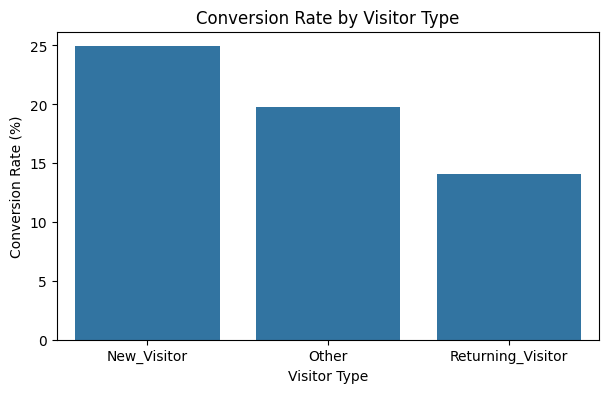

In [18]:
# Visualizing conversion rate across visitor types
plt.figure(figsize=(7, 4))

sns.barplot(
    x=visitor_conversion.index,
    y=visitor_conversion.values
)

plt.title("Conversion Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Conversion Rate (%)")

plt.show()

In [19]:
## 2. Product Engagement and Purchase Conversion

# Compare product browsing behavior by conversion outcome
product_engagement = (
    df.groupby("Revenue")[
        ["ProductRelated", "ProductRelated_Duration"]
    ]
    .median()
    .round(2)
)

product_engagement

,ProductRelated,ProductRelated_Duration
Revenue,,
False,16.0,526.00
True,29.0,1109.91


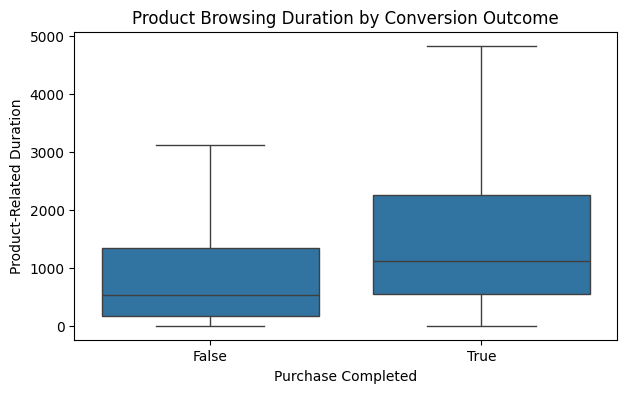

In [20]:
# Visualize product browsing duration for converting and non-converting sessions
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration",
    showfliers=False
)

plt.title("Product Browsing Duration by Conversion Outcome")
plt.xlabel("Purchase Completed")
plt.ylabel("Product-Related Duration")

plt.show()

In [21]:
## 3. Bounce Rate, Exit Rate, and Purchase Conversion

# Compare average bounce and exit rates by conversion outcome
bounce_exit_summary = (
    df.groupby("Revenue")[["BounceRates", "ExitRates"]]
    .mean()
    .round(4)
)

bounce_exit_summary

,BounceRates,ExitRates
Revenue,,
False,0.0232,0.0455
True,0.0051,0.0196


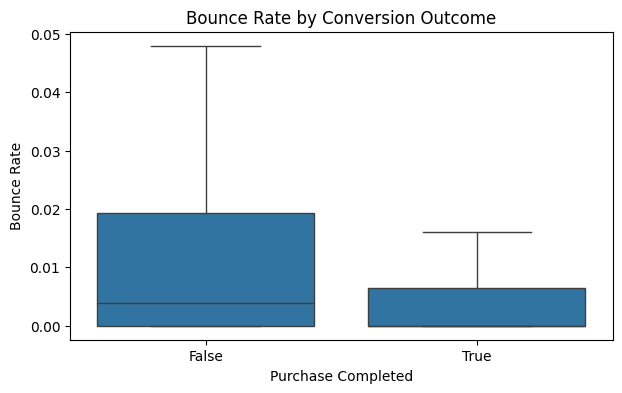

In [22]:
# Visualize bounce rate by conversion outcome
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Revenue",
    y="BounceRates",
    showfliers=False
)

plt.title("Bounce Rate by Conversion Outcome")
plt.xlabel("Purchase Completed")
plt.ylabel("Bounce Rate")

plt.show()

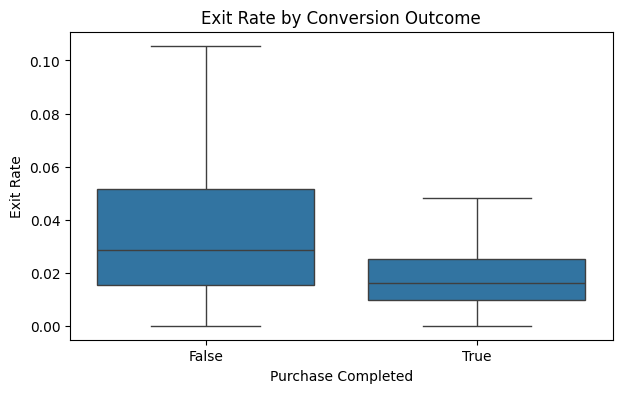

In [23]:
# Visualize exit rate by conversion outcome
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ExitRates",
    showfliers=False
)

plt.title("Exit Rate by Conversion Outcome")
plt.xlabel("Purchase Completed")
plt.ylabel("Exit Rate")

plt.show()

In [24]:
## 4. Monthly Purchase Conversion Rate

# Calculate monthly conversion rate
monthly_conversion = (
    df.groupby("Month")["Revenue"]
    .mean()
    .mul(100)
    .round(2)
)

monthly_conversion

,Revenue
Month,
Aug,17.55
Dec,12.66
Feb,1.66
Jul,15.28
June,10.18
Mar,10.32
May,10.96
Nov,25.49
Oct,20.95


In [25]:
month_order = [
    "Feb", "Mar", "May", "June",
    "Jul", "Aug", "Sep", "Oct",
    "Nov", "Dec"
]

monthly_conversion = monthly_conversion.reindex(month_order)

monthly_conversion

,Revenue
Month,
Feb,1.66
Mar,10.32
May,10.96
June,10.18
Jul,15.28
Aug,17.55
Sep,19.20
Oct,20.95
Nov,25.49


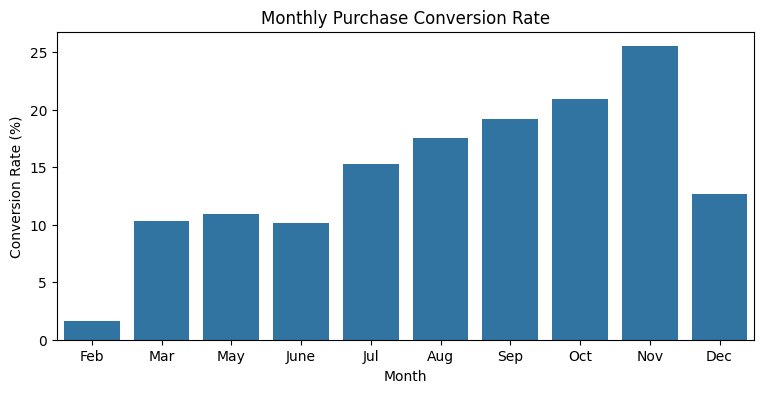

In [26]:
# Visualize monthly conversion rate
plt.figure(figsize=(9, 4))

sns.barplot(
    x=monthly_conversion.index,
    y=monthly_conversion.values
)

plt.title("Monthly Purchase Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")

plt.show()

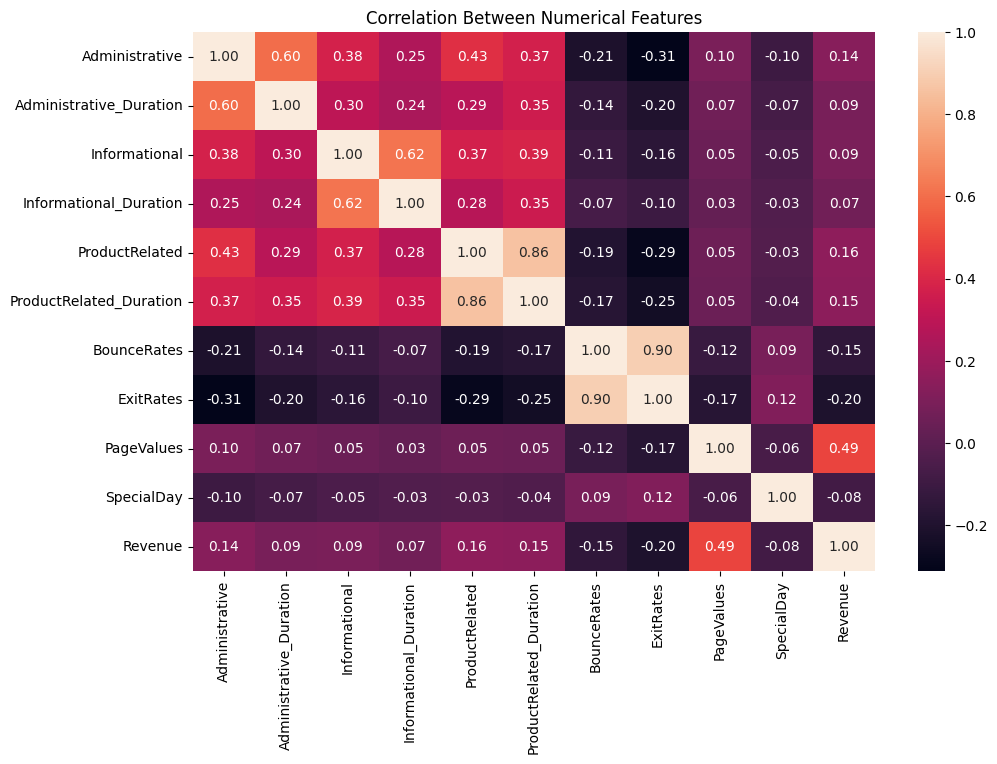

In [27]:
## 5. Correlation Between Numerical Features

numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

correlation_data = df[numeric_features].copy()
correlation_data["Revenue"] = df["Revenue"].astype(int)

plt.figure(figsize=(11, 7))

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()
